In [1]:
using SpecialFunctions
using LinearAlgebra
using Plots, LaTeXStrings
using Struve
using KrylovKit
using SparseArrays
using Arpack  # For sparse eigenvalue computations
using QuadGK
using ForwardDiff
using FFTW
using Statistics
using Measures
using TensorOperations
include("module_simple.jl")
using .exciton

In [2]:
color_list_for_plot = [RGB(0.0, 0.45, 0.74),  # blue for exciton,
    RGB(0.2, 0.2, 0.5),
    RGB(0.4, 0.4, 0.3),
    RGB(0.6, 0.0, 0.2),  # deep crimson red
    RGB(1.0, 0.55, 0.0),  # stronger amber orange
    :green]

marker_list_for_plot = [:circle,  # blue for exciton
    :circle,
    :circle,
    :utriangle,  # deep crimson red
    :dtriangle,  # stronger amber orange
    :diamond]

function wrap_to_positive(θ)
    return mod(θ, 2π)
end

function wrap_to_pi(θ)
    return mod(θ + π, 2π) - π
end

wrap_to_pi (generic function with 1 method)

# Fig 2a

In [3]:
const lambda=0.75
const r0=1.5
Nsample = 24
lattice = GrapheneLattice();
VInt = InteractionMatrix(lattice, Nsample; lambda, r0)
delta_value = 1
t0 = 0.5 * delta_value
t1 = 0.9 * t0
t2 = 1 * t0
t3 = t0
graphene_sys = GrapheneBSE(lattice, [0.0, 0], [t1, t2, t3], delta_value, Nsample);
graphene_sys = add_bse_kernel(graphene_sys, VInt)

alphalist = 0.0:0.1:1.0
eigenvalue_number = 80
energy_list = zeros(Float64, length(alphalist), eigenvalue_number)

Nsample = 24
lattice = GrapheneLattice();
VInt = InteractionMatrix(lattice, Nsample; lambda, r0)

s = 0
for alphacoefficient in alphalist
    graphene_sys = GrapheneBSE(lattice, [alphacoefficient / Nsample, 0.0], [t1, t2, t3], delta_value, Nsample)
    graphene_sys = add_bse_kernel(graphene_sys, VInt)
    s += 1
    println(alphacoefficient)

    bsemat = graphene_sys.BSEKernel
    xlen = size(bsemat)[1]
    x0 = rand(xlen)
    valslist, vecslist, info = eigsolve(bsemat, x0, eigenvalue_number, :SR,
        krylovdim=120, tol=1e-8, maxiter=20,
        verbosity=0, ishermitian=true)
    energy_list[s, :] .= real(valslist[1:eigenvalue_number])
end

0.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
1.0


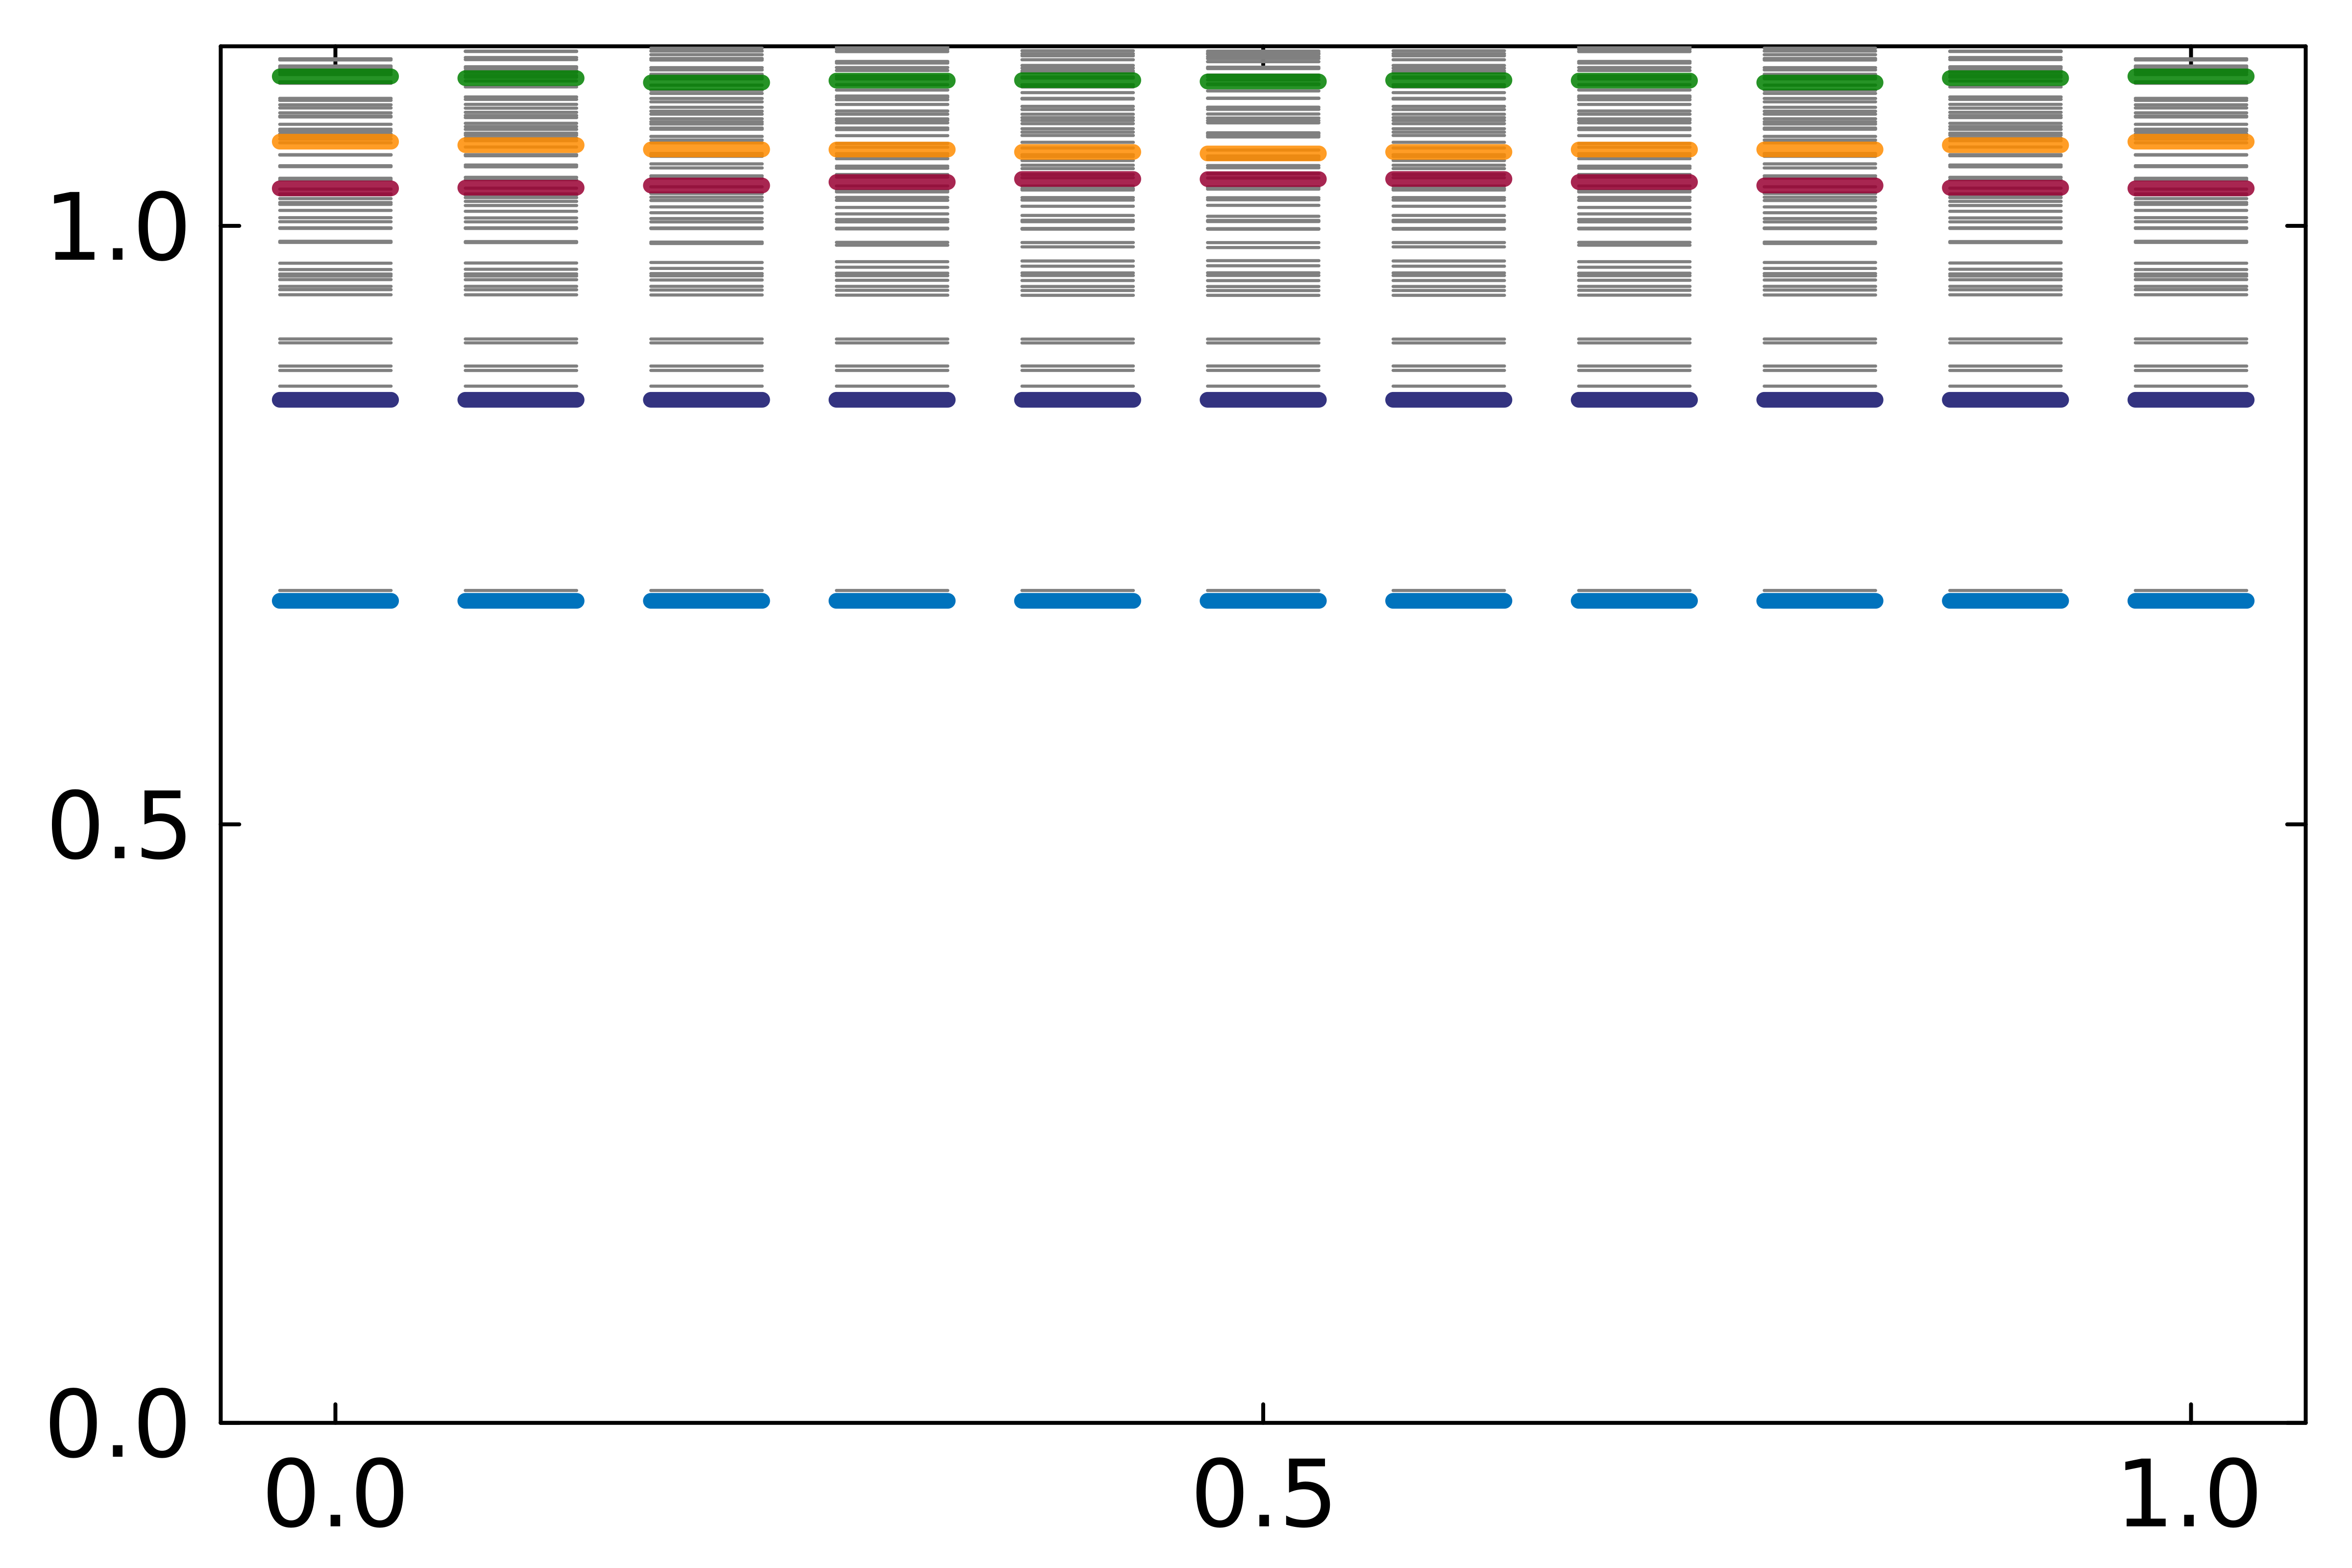

"/Users/xuyang/numerical_library/github/exciton/src/fig2/fig2a.png"

In [4]:
color_list_for_plot = [RGB(0.0, 0.45, 0.74),  # blue for exciton,
    RGB(0.2, 0.2, 0.5),
    RGB(0.4, 0.4, 0.3),
    RGB(0.6, 0.0, 0.2),  # deep crimson red
    RGB(1.0, 0.55, 0.0),  # stronger amber orange
    :green]

marker_list_for_plot = [:circle,  # blue for exciton
    :circle,
    :circle,
    :utriangle,  # deep crimson red
    :dtriangle,  # stronger amber orange
    :diamond]

windowrange = (0.0, 1.15)
offset = count(<(1), energy_list[1, :])

# Setup
x_values = 0.0:0.1:1.0
line_length = 0.06
delocalized_list = [10, 18, 35] # above gap

de1, de2, de3 = offset .+ delocalized_list
highlight_map = Dict(de1 => color_list_for_plot[4], de2 => color_list_for_plot[5], de3 => color_list_for_plot[6])

# Plot attributes
plot_attrs = Dict(
    :xgrid => false, :ygrid => false, :framestyle => :box,
    :xticks => ([0, 0.5, 1.0], [0, 0.5, 1.0]),
    :yticks => ([0, 0.5, 1.0, 1.5], [0, 0.5, 1.0, 1.5]),
    :tickfontsize => 16,
    :xlabelfontsize => 18,
    :ylabelfontsize => 18,
    :dpi => 800,
    :ylims => windowrange
)

# Helper function
function draw_lines!(x_vals, y_vals; lw=1.3, color=:grey, alphaval=1, attrs=Dict())
    for (x, y) in zip(x_vals, y_vals)
        plot!([x - line_length / 2, x + line_length / 2], [y, y];
            lw=lw, color=color, label=false, alpha=alphaval, attrs...)
    end
end

# Initialize plot
p = plot()



# Plot rows 2:180, with exceptions for highlighted ones
for row in 2:80
    if row != 3
        y_vals = real(energy_list)[:, row]
        if !haskey(highlight_map, row)
            draw_lines!(x_values, y_vals; lw=0.8, color=:grey, attrs=plot_attrs)
        end
    end
end

for row in 2:80
    if row != 3
        y_vals = real(energy_list)[:, row]
        if haskey(highlight_map, row)
            draw_lines!(x_values, y_vals; lw=4, color=highlight_map[row], alphaval=0.85, attrs=plot_attrs)
        end
    end
end

# Plot the blue curve (row = 1)
for row = 1:2
    y_vals = real(energy_list)[:, 2*row-1]
    draw_lines!(x_values, y_vals; lw=4, color=color_list_for_plot[row], attrs=plot_attrs)
end

# Display and save
display(p)
savefig(p, "fig2a.png")


# Fig 2ainset

This is round 1
This is round 2
This is round 3
This is round 4
This is round 5
This is round 6


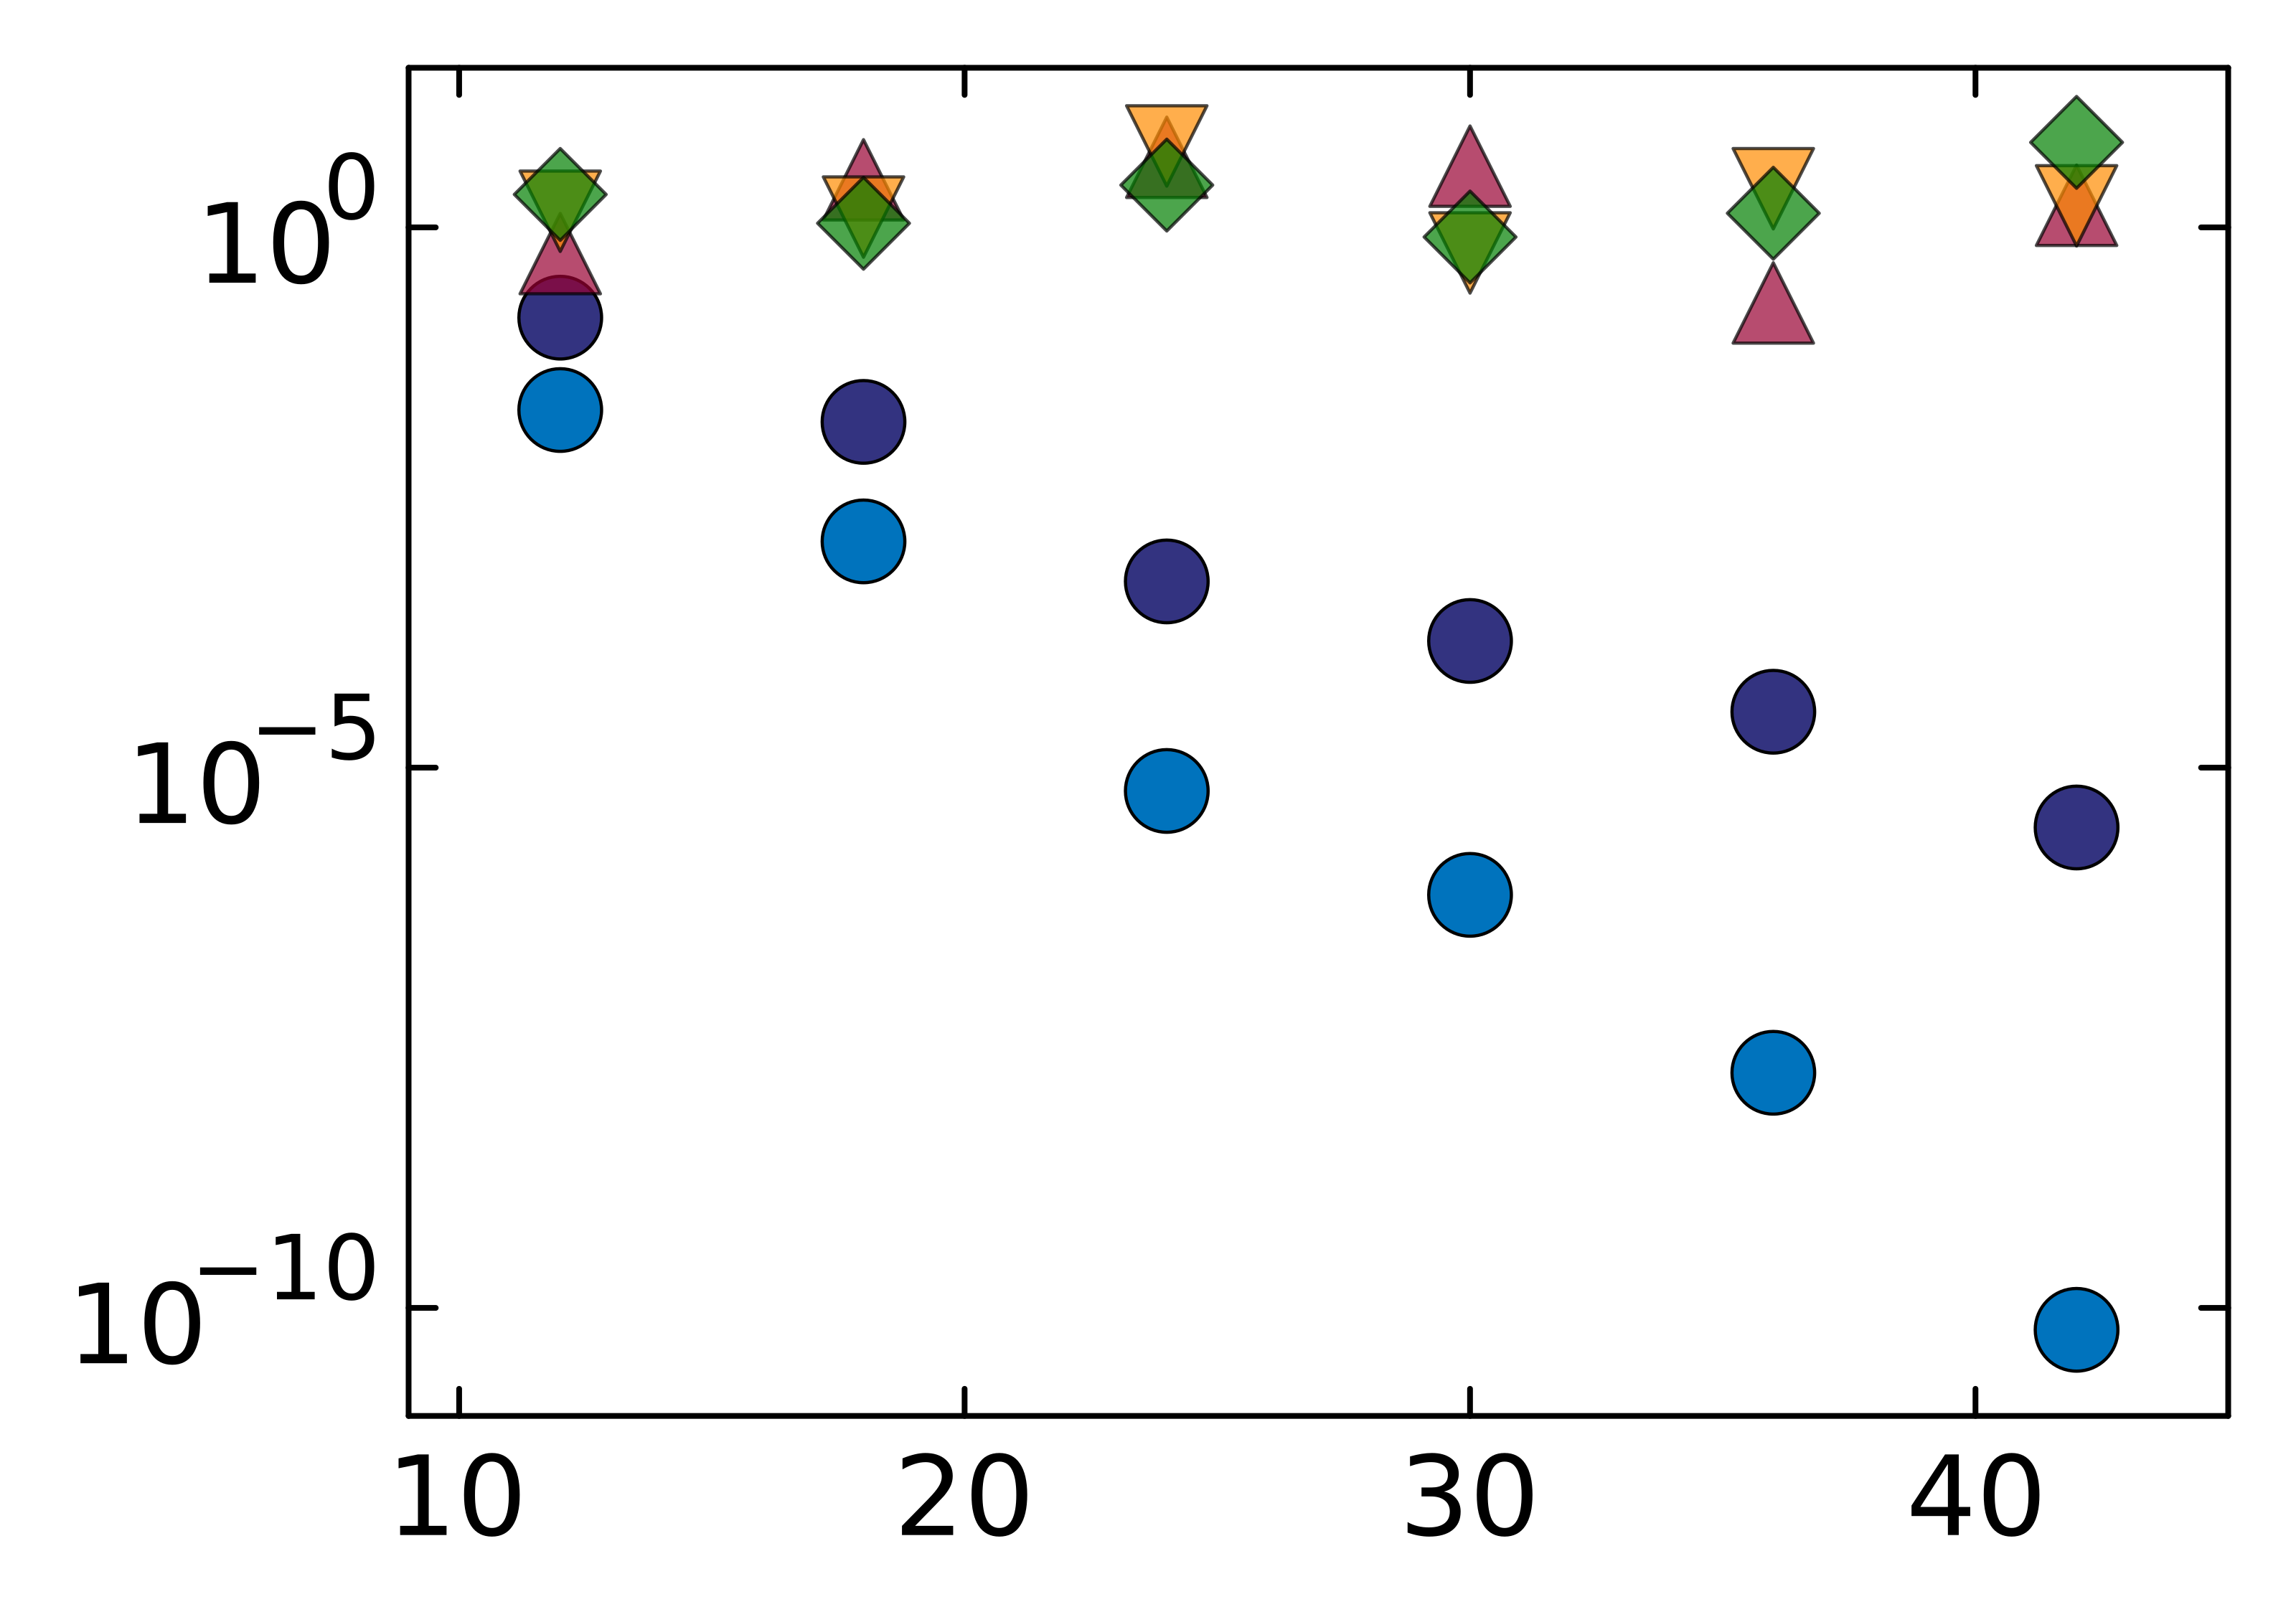

"/Users/xuyang/numerical_library/github/exciton/src/fig2/fig2ainset.png"

In [5]:
alphalist = [0.0, 0.5]
eigenvalue_number = 80
roundval = 5
starting = 12
Nsample_list = collect(starting:6:(starting+6*roundval))
ET_list = zeros(Float64, length(Nsample_list), 6)

ind = 0
localized_list = [1, 3, 5]
for (lsize, Nsample) in enumerate(Nsample_list)
    ind += 1
    println("This is round $ind")
    energy_list = zeros(Float64, 2, 6)

    lattice = GrapheneLattice()
    VInt = InteractionMatrix(lattice, Nsample; lambda, r0)
    for (s, α) in enumerate(alphalist)
        graphene_sys = GrapheneBSE(lattice, [α / Nsample, 0], [t1, t2, t3], delta_value, Nsample)
        graphene_sys = add_bse_kernel(graphene_sys, VInt)
        bsemat = graphene_sys.BSEKernel
        xlen = size(bsemat)[1]
        x0 = rand(xlen)

        enum = 30
        if Nsample > 15
            enum = 80
        end

        valslist, vecslist, info = eigsolve(bsemat, x0, enum, :SR,
            krylovdim=140, tol=1e-8, maxiter=20,
            verbosity=0, ishermitian=true)

        dej = 0
        for items in localized_list
            dej += 1
            energy_list[s, dej] = real(valslist[items])

        end

        offset = count(<(1), valslist[:])

        for items in delocalized_list
            dej += 1
            energy_list[s, dej] = real(valslist[offset+items])
        end
    end

    # Save scaled energy difference
    ET_list[lsize, :] .= (energy_list[1, :] .- energy_list[2, :]) .* Nsample^2
end

# Plot exciton Thouless number
thoulessplot = scatter(Nsample_list[1:end], abs.(ET_list[1:end, 1]), yscale=:log10,
    lw=2,
    color=color_list_for_plot[1], framestyle=:box,
    xticks=([10, 20, 30, 40, 50]),
    yticks=[1, 1e-5, 1e-10],
    tickfontsize=13,
    xgrid=false, ygrid=false,
    ms=8, label=false,
    ylabelfontsize=16, xlabelfontsize=16, xlim=(9, 45), ylim=(10^(-11), 30), dpi=800, size=(400, 280))

for row = 2:2
    scatter!(Nsample_list[1:end], abs.(ET_list[1:end, row]), yscale=:log10, lw=2, ms=8, label=false,
        color=color_list_for_plot[row])
end

for row = 4:6
    mssize = 7
    if row == 6
        mssize = 8
    end
    scatter!(Nsample_list, abs.(ET_list[:, row]),
        ms=mssize, label=false, color=color_list_for_plot[row], alpha=0.7, markershape=marker_list_for_plot[row])
end
display(thoulessplot)
savefig("fig2ainset.png")


# Fig 2b

In [6]:
alphalist = 0.000:0.1:1.000
wilson_number = 80
Nsample = 24
eigenvalue_number = 80

wilson_list = zeros(Float64, length(alphalist), wilson_number)

# Reciprocal lattice vectors
lattice = GrapheneLattice()
VInt = InteractionMatrix(lattice, Nsample; lambda,r0)

s = 0
for α in alphalist
    s += 1
    println(α)
    flush(stdout)
    graphene_sys = GrapheneBSE(lattice, [α / Nsample, 0], [t1, t2, t3], delta_value, Nsample)
    graphene_sys = add_bse_kernel(graphene_sys, VInt)
    bsemat = graphene_sys.BSEKernel
    xlen = size(bsemat)[1]
    x0 = rand(xlen)
    valslist, vecslist, info = eigsolve(bsemat, x0, eigenvalue_number, :SR,
        krylovdim=120, tol=1e-8, maxiter=20,
        verbosity=0, ishermitian=true)

    precomputed = Dict{Tuple{Int,Int},Tuple{Matrix,Matrix,Matrix}}()

    for xdim = 1:Nsample, ydim = 1:Nsample
        b1, b2 = lattice.b1, lattice.b2
        R1, R2 = lattice.R1, lattice.R2
        k = (b1 * xdim + b2 * ydim) / Nsample
        kx, ky = k
        umat, _ = exciton.eigensystem(k; t1, t2, t3, delta=delta_value,
            A=[α / Nsample, 0], R1, R2, lattice)
        Avec = α * b1 / Nsample
        jx = jxop(kx, ky; t1, t2, t3, delta=delta_value, A=Avec, lattice)
        jy = jyop(kx, ky; t1, t2, t3, delta=delta_value, A=Avec, lattice)
        precomputed[(xdim, ydim)] = (umat, jx, jy)
    end

    for i = 1:wilson_number
        psi = vecslist[i]
        pump_sum = 0.0
        relax_sum = 0.0
        for xdim = 1:Nsample, ydim = 1:Nsample
            umat, jx, jy = precomputed[(xdim, ydim)]
            index = ham_index(xdim, ydim; xlength=Nsample, ylength=Nsample)

            pump_sum += (umat'*(jx+sqrt(3)*jy)*umat)[2, 1] * psi[index]
            relax_sum += (umat'*(jx-sqrt(3)*jy)*umat)[2, 1] * psi[index]
        end
        wilson_list[s, i] = angle(pump_sum * conj(relax_sum))
    end
end


0.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
1.0


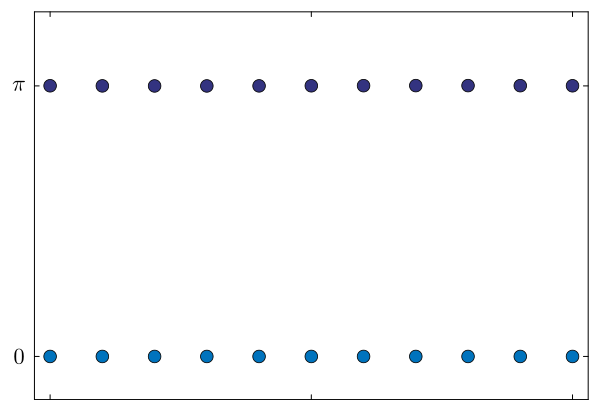

In [7]:
msdefined = 7

common_kwargs = (
    legend=false,
    label="exciton",
    ylim=(-0.5, 4),
    framestyle=:box,
    xticks=([0, 0.5, 1], []),
    yticks=([0, 3.14], [L"0", L"\pi"]),
    tickfontsize=15,
    xgrid=false,
    ygrid=false,
    ms=msdefined,
    ylabelfontsize=20,
    xlabelfontsize=20,
    bottom_margin=-3.9mm,
    markershape=marker_list_for_plot[1],
)

p_gs = scatter(alphalist, wrap_to_pi.(wilson_list[:, 1]);
    color=color_list_for_plot[1], common_kwargs...)

scatter!(alphalist, wrap_to_positive.(wilson_list[:, 3]);
    color=color_list_for_plot[2], common_kwargs...)


In [8]:
greenlist = wrap_to_pi.(wilson_list[:, de3])
greenlist[5:7] .= wrap_to_positive.(greenlist[5:7])

msdefined = 7
yrange = (-3.5, 4.8)
p_excited = scatter(alphalist, wrap_to_positive.(wilson_list[:, de1]),
    label="delocalized state # 2", ylim=yrange, legend=false,
    color=color_list_for_plot[4], framestyle=:box, xticks=([0, 0.5, 1]), yticks=([-pi,0, pi], [L"-\pi", L"0", L"\pi"]), markershape=marker_list_for_plot[4], tickfontsize=14,
    xgrid=false, ygrid=false, ms=msdefined,
    ylabelfontsize=17, xlabelfontsize=17)
scatter!(alphalist, wrap_to_positive.(wilson_list[:, de2]), color=color_list_for_plot[5], markershape=marker_list_for_plot[5], markersize=msdefined,
    legendfontsize=6, ylim=yrange)
scatter!(alphalist, greenlist, color=color_list_for_plot[6], markershape=marker_list_for_plot[6], markersize=msdefined,
    legendfontsize=6, ylim=yrange, top_margin=-1.9mm)

x = [0.0, 0.1]
y = [wrap_to_positive.(wilson_list[:, de1])[1], wrap_to_positive.(wilson_list[:, de1])[2]]

# Compute slope and intercept
m = (y[2] - y[1]) / (x[2] - x[1])
b = y[1] - m * x[1]

# Extrapolation range (extend beyond original points)
x_extrap = LinRange(0.0, 1, 100)
y_extrap = m .* x_extrap .+ b
# Plot
plot!(x_extrap, y_extrap, lw=1, color=color_list_for_plot[4], ls=:dash)

x = [0.0, 0.1]
y = [wrap_to_positive.(wilson_list[:, de2])[1], wrap_to_positive.(wilson_list[:, de2])[2]]

# Compute slope and intercept
m = (y[2] - y[1]) / (x[2] - x[1])
b = y[1] - m * x[1]

# Extrapolation range (extend beyond original points)
x_extrap = LinRange(0.0, 1, 100)
y_extrap = m .* x_extrap .+ b
# Plot
plot!(x_extrap, y_extrap, lw=1, color=color_list_for_plot[5], ls=:dash)

x = [0.0, 0.1]
y = [wrap_to_pi.(wilson_list[:, de3])[1], wrap_to_pi.(wilson_list[:, de3])[2]]

# Compute slope and intercept
m = (y[2] - y[1]) / (x[2] - x[1])
b = y[1] - m * x[1]

# Extrapolation range (extend beyond original points)
x_extrap = LinRange(0.0, 1, 100)
y_extrap = m .* x_extrap .+ b
# Plot
plot!(x_extrap, y_extrap, lw=1, color=color_list_for_plot[6], ls=:dash)

gr()
porigin = plot(p_gs, layout=(2, 1), index=1, dpi=800)
# Add the second plot to the bottom subplot (index 2)
plot!(porigin, p_excited, layout=(2, 1), index=2)
savefig("fig2b.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig2/fig2b.png"

# Fig 2c

In [9]:
alphalist = 0.01:0.1:1
selected_states = [1, 3]

ET_Wilson_tensor = zeros(Float64, length(Nsample_list), length(alphalist), length(selected_states) + 3)

for (lsize, Nsample) in enumerate(Nsample_list)
    println("Running for Nsample = $Nsample")
    flush(stdout)
    lattice = GrapheneLattice()
    VInt = InteractionMatrix(lattice, Nsample; lambda, r0)

    for (jue, α) in enumerate(alphalist)

        graphene_sys = GrapheneBSE(lattice, [α / Nsample, 0], [t1, t2, t3], delta_value, Nsample)
        graphene_sys = add_bse_kernel(graphene_sys, VInt)
        bsemat = graphene_sys.BSEKernel
        xlen = size(bsemat)[1]
        x0 = rand(xlen)
        enum=0
        if Nsample < 15
            enum = 30
        else
            enum = 80
        end
        valslist, vecslist, info = eigsolve(bsemat, x0, enum, :SR,
            krylovdim=140, tol=1e-8, maxiter=20,
            verbosity=0, ishermitian=true)

        offset = count(<(1), valslist[:])

        precomputed = Dict{Tuple{Int,Int},Tuple{Matrix,Matrix,Matrix}}()

        for xdim = 1:Nsample, ydim = 1:Nsample
            b1, b2 = lattice.b1, lattice.b2
            R1, R2 = lattice.R1, lattice.R2
            k = (b1 * xdim + b2 * ydim) / Nsample
            kx, ky = k
            umat, _ = exciton.eigensystem(k; t1, t2, t3, delta=delta_value,
                A=[α / Nsample, 0], R1, R2, lattice)
            Avec = α * b1 / Nsample
            jx = jxop(kx, ky; t1, t2, t3, delta=delta_value, A=Avec, lattice)
            jy = jyop(kx, ky; t1, t2, t3, delta=delta_value, A=Avec, lattice)
            precomputed[(xdim, ydim)] = (umat, jx, jy)
        end

        sindicator = 0
        # Loop over selected states
        for (sidx, si) in enumerate(selected_states)
            sindicator += 1
            psi = vecslist[si]
            pump_sum = 0.0
            relax_sum = 0.0

            for xdim = 1:Nsample, ydim = 1:Nsample
                umat, jx, jy = precomputed[(xdim, ydim)]
                index = ham_index(xdim, ydim; xlength=Nsample, ylength=Nsample)

                pump_sum += (umat'*(jx+sqrt(3)*jy)*umat)[2, 1] * psi[index]
                relax_sum += (umat'*(jx-sqrt(3)*jy)*umat)[2, 1] * psi[index]
            end
            ET_Wilson_tensor[lsize, jue, sidx] = angle(pump_sum * conj(relax_sum))
        end

        for items in delocalized_list
            sindicator += 1

            psi = vecslist[offset+items]
            pump_sum = 0.0
            relax_sum = 0.0

            for xdim = 1:Nsample, ydim = 1:Nsample
                umat, jx, jy = precomputed[(xdim, ydim)]
                index = ham_index(xdim, ydim; xlength=Nsample, ylength=Nsample)

                pump_sum += (umat'*(jx+sqrt(3)*jy)*umat)[2, 1] * psi[index]
                relax_sum += (umat'*(jx-sqrt(3)*jy)*umat)[2, 1] * psi[index]
            end
            ET_Wilson_tensor[lsize, jue, sindicator] = angle(pump_sum * conj(relax_sum))
        end
    end
end

# Initialize container for standard deviations
std_over_alpha = zeros(Float64, length(Nsample_list), length(selected_states) + 3)
# Loop to compute std dev over α for each L and each eigenstate
sset = [2]
for (lsize, _) in enumerate(Nsample_list)
    for localized_ind = 1:(length(selected_states)+3)
        num = ET_Wilson_tensor[lsize, 1, localized_ind]
        data = 0
        if abs(num) < 3
            data = wrap_to_pi.(ET_Wilson_tensor[lsize, :, localized_ind])
        elseif abs(abs(num) - pi) < 3
            data = wrap_to_positive.(ET_Wilson_tensor[lsize, :, localized_ind])
        end
        std_over_alpha[lsize, localized_ind] = std(data)
    end
end

Running for Nsample = 12
Running for Nsample = 18
Running for Nsample = 24
Running for Nsample = 30
Running for Nsample = 36
Running for Nsample = 42


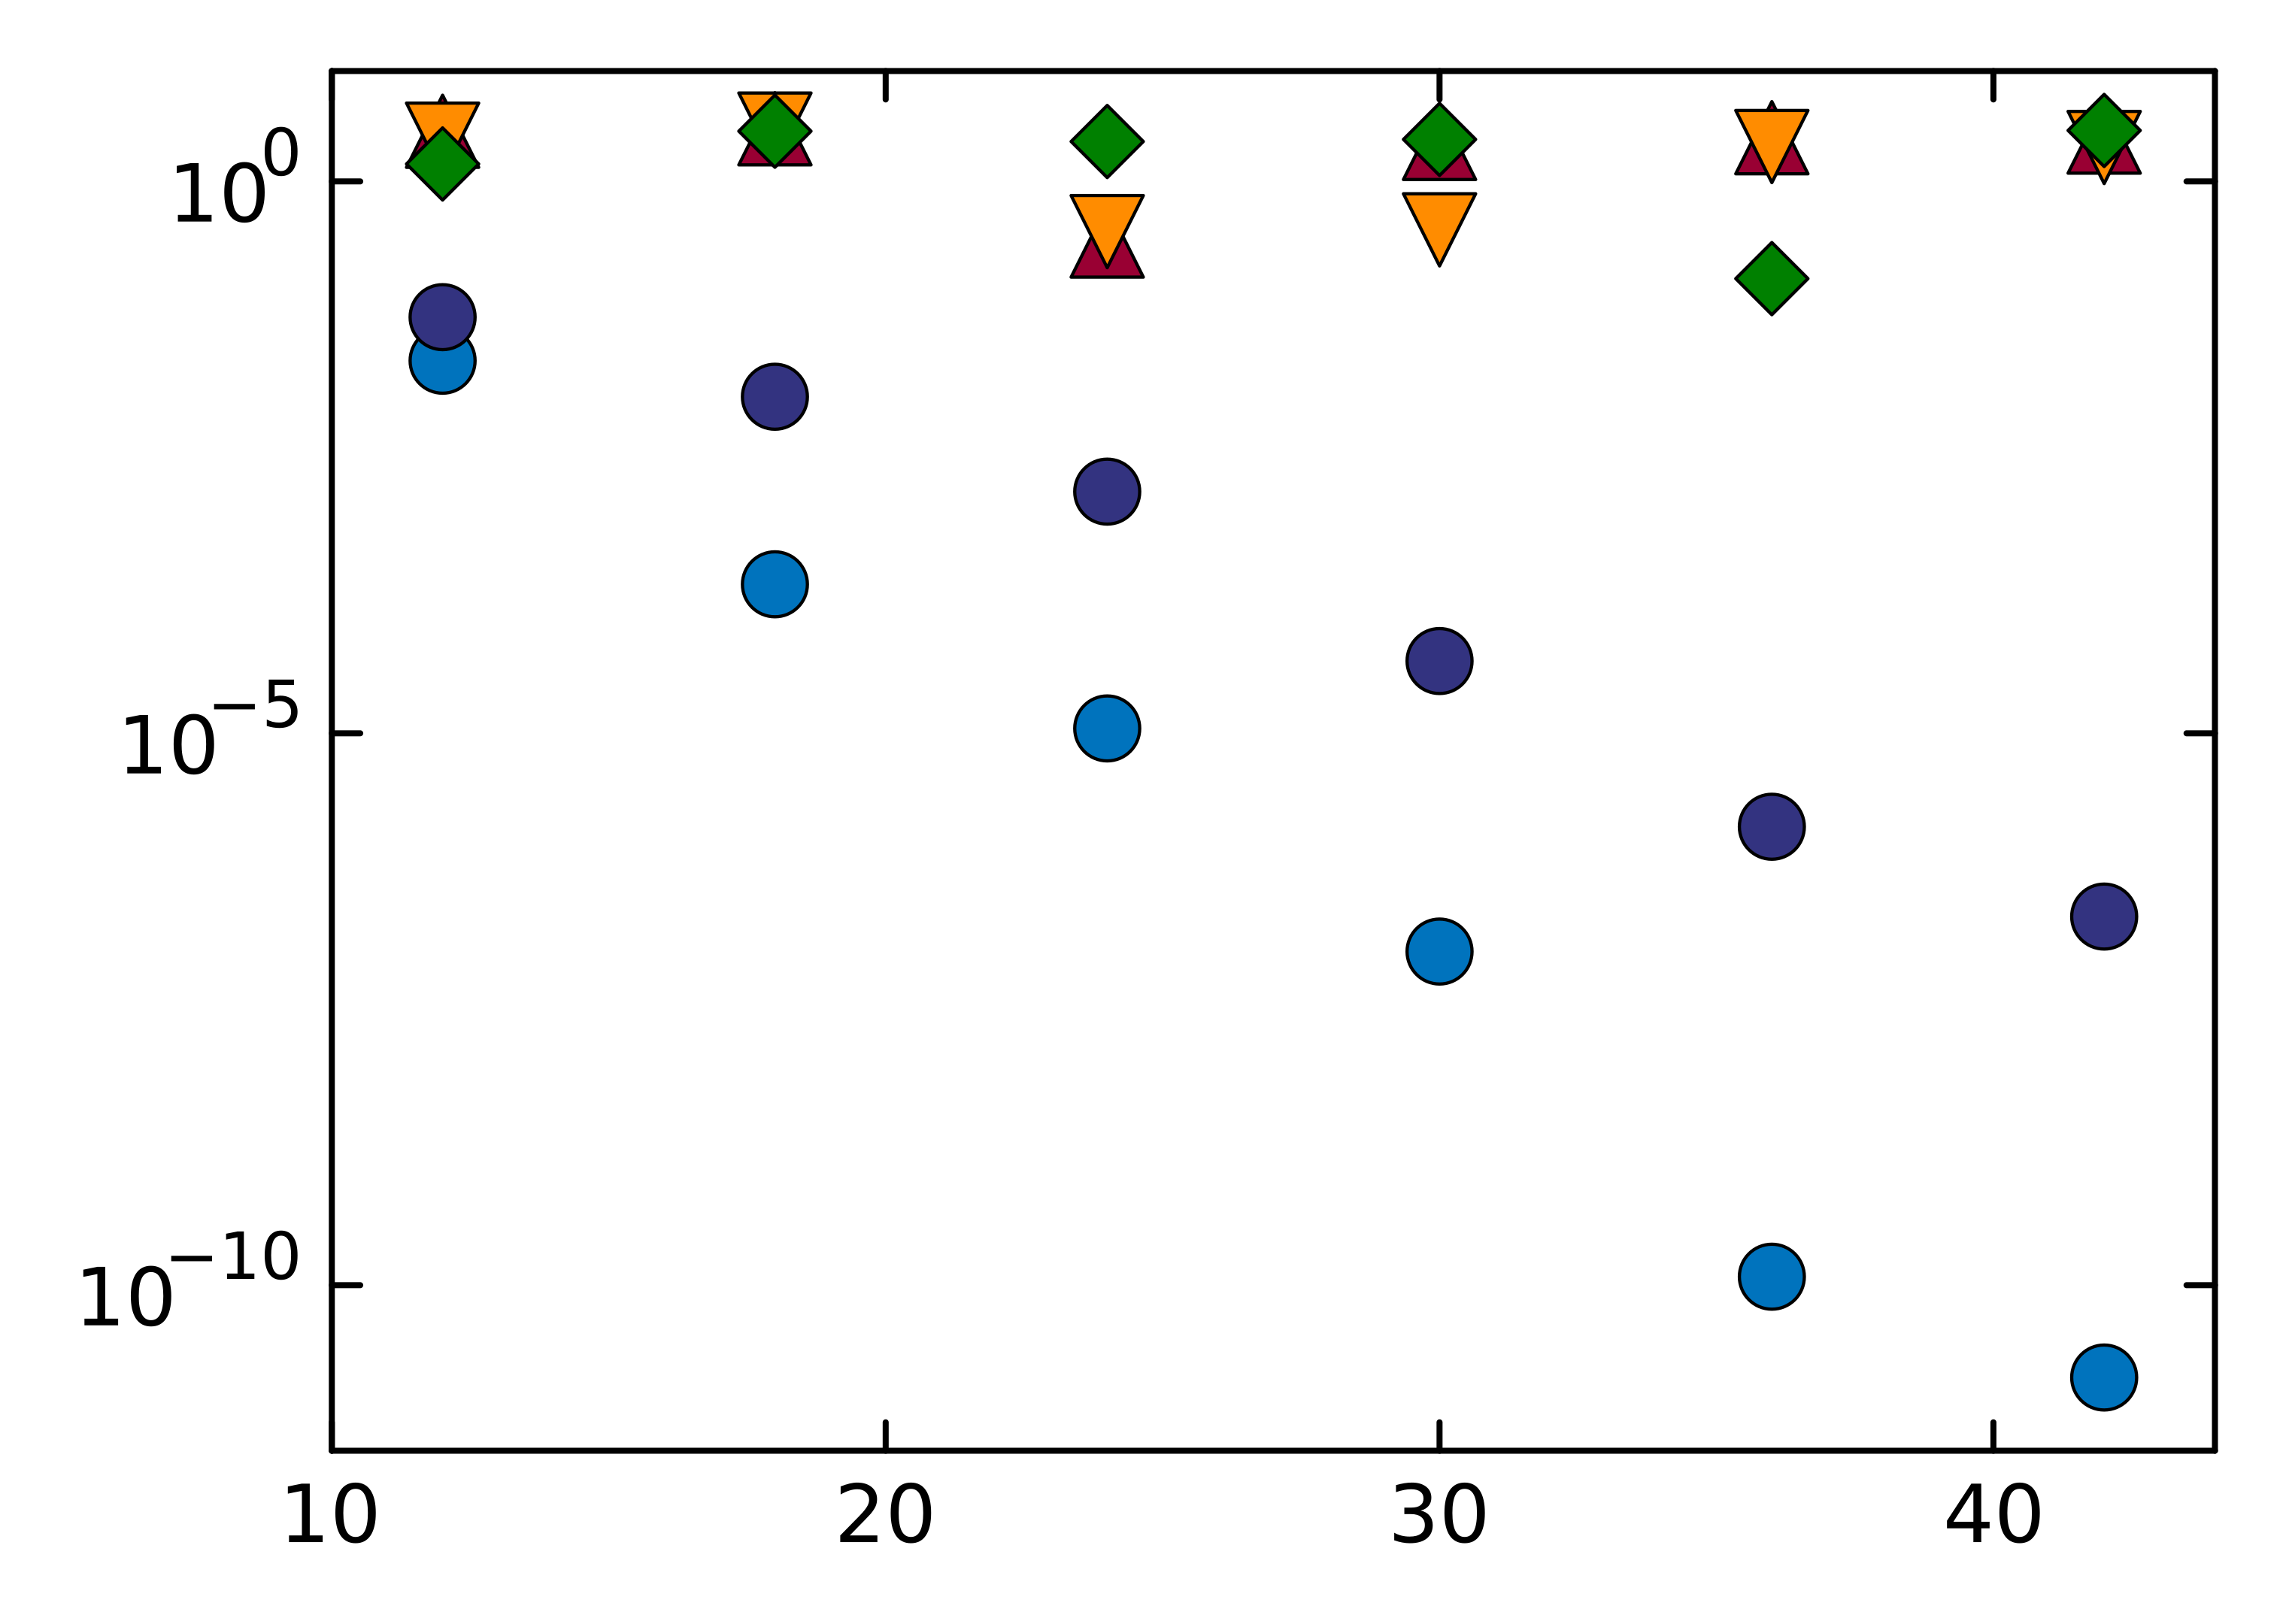

"/Users/xuyang/numerical_library/github/exciton/src/fig2/fig2c.png"

In [10]:
# Plot state 1 (first column)
pp = scatter(Nsample_list,
    std_over_alpha[:, 1],
    yscale=:log10,
    framestyle=:box,
    xticks=([10, 20, 30, 40]),
    yticks=[1, 1e-5, 1e-10],
    tickfontsize=9,
    xgrid=false,
    ygrid=false,
    ms=6,
    label=false,
    ylabelfontsize=12,
    xlabelfontsize=12,
    dpi=800,
    size=(380, 270),
    color=color_list_for_plot[1], xlim=(10, 44), ylim=(10^(-11.5), 10))

for (j, c) in zip(2:2, color_list_for_plot[2:2])
    scatter!(Nsample_list, std_over_alpha[:, j], ms=6, label=false, color=c)
end

for (j, c, m) in zip(3:5, color_list_for_plot[4:6], marker_list_for_plot[4:6])
    scatter!(Nsample_list, std_over_alpha[:, j], ms=6, label=false, color=c, markershape=m)
end
display(pp)
# Optional: save figure
savefig("fig2c.png")
